In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

In [ ]:
def linear_least_squares(x, y):
    """
    Fit the linear model  f(x) = a*x + b  to (x, y) data.

    Parameters
    ----------
    x : array-like, shape (n,)
    y : array-like, shape (n,)

    Returns
    -------
    a, b : floats   (slope and intercept)
    residual : float  (2-norm of residual vector)
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Design matrix: each row is [x_i, 1]
    A = np.column_stack([x, np.ones_like(x)])

    # Solve in the least-squares sense
    coeffs, residuals, rank, sv = np.linalg.lstsq(A, y, rcond=None)
    a, b = coeffs

    # Compute residual norm manually (lstsq residuals may be empty for underdetermined)
    residual = np.linalg.norm(A @ coeffs - y)

    return a, b, residual

linear_least_squares() defined.


In [ ]:
# Full dataset – days 1-18
x_full = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18], dtype=float)
y_full = np.array([1,1,3,3,3,3,4,6,6,9,13,15,17,29,47,59,89,123], dtype=float)

# Linearise: ỹ = ln(y).  Note: y=1 gives ỹ=0
y_tilde_full = np.log(y_full)

# Fit linear model to (x, ỹ)
a_full, b_full, res_full = linear_least_squares(x_full, y_tilde_full)

print(f"Full dataset – linear fit on (x, ln y):")
print(f"  a = {a_full:.6f}")
print(f"  b = {b_full:.6f}")
print(f"  Residual norm = {res_full:.6f}")
print(f"  Exponential model: f(x) = exp({a_full:.4f}*x + ({b_full:.4f}))")

Full dataset – linear fit on (x, ln y):
  a = 0.268342
  b = -0.312391
  Residual norm = 1.039157
  Exponential model: f(x) = exp(0.2683*x + (-0.3124))


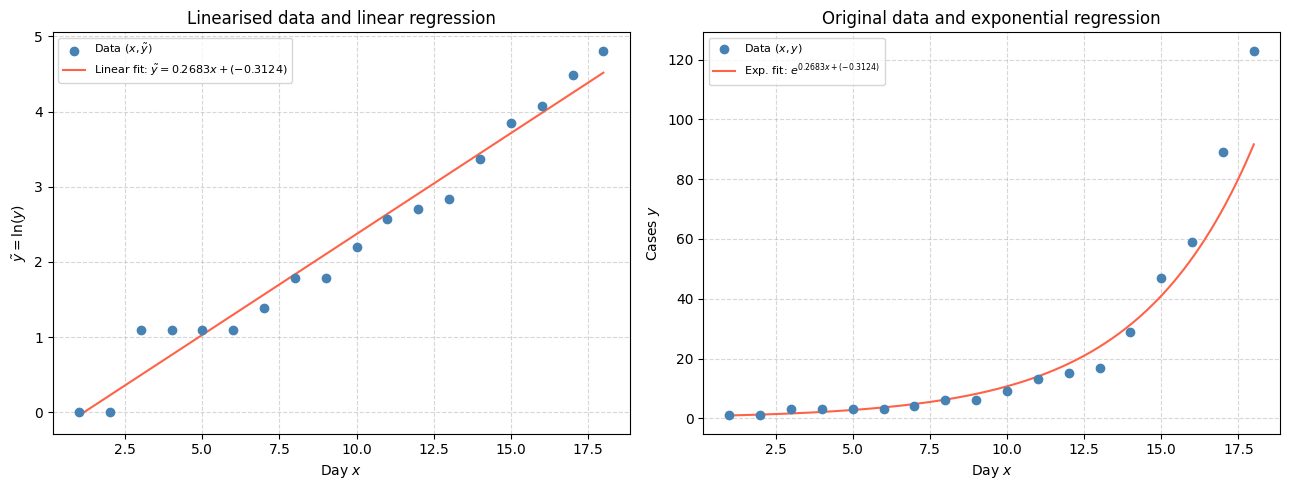

Plot saved.


In [30]:
x_plot = np.linspace(1, 18, 300)

# Linear regression line in log-space
y_linear_fit = a_full * x_plot + b_full

# Exponential regression curve in original space
y_exp_fit = np.exp(a_full * x_plot + b_full)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: linearised (log) space ---
ax = axes[0]
ax.scatter(x_full, y_tilde_full, color='steelblue', zorder=5, label='Data $(x,\\tilde{y})$')
ax.plot(x_plot, y_linear_fit, color='tomato', label=f'Linear fit: $\\tilde{{y}} = {a_full:.4f}x + ({b_full:.4f})$')
ax.set_xlabel('Day $x$')
ax.set_ylabel('$\\tilde{y} = \\ln(y)$')
ax.set_title('Linearised data and linear regression')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.5)

# --- Right: original space ---
ax = axes[1]
ax.scatter(x_full, y_full, color='steelblue', zorder=5, label='Data $(x, y)$')
ax.plot(x_plot, y_exp_fit, color='tomato',
        label=f'Exp. fit: $e^{{{a_full:.4f}x + ({b_full:.4f})}}$')
ax.set_xlabel('Day $x$')
ax.set_ylabel('Cases $y$')
ax.set_title('Original data and exponential regression')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print("Plot saved.")

In [31]:
x_pred = 30.0
y_pred_full = np.exp(a_full * x_pred + b_full)
y_actual = 1029.0

rel_error_full = abs(y_pred_full - y_actual) / y_actual * 100

print(f"Extrapolation to day {int(x_pred)} (full dataset):")
print(f"  Model prediction : {y_pred_full:.2f}")
print(f"  Actual value     : {y_actual:.0f}")
print(f"  Relative error   : {rel_error_full:.2f}%")

Extrapolation to day 30 (full dataset):
  Model prediction : 2293.60
  Actual value     : 1029
  Relative error   : 122.90%


In [32]:
# Reduced dataset – only days 1, 4, 7, 10, 13, 16
x_miss = np.array([1, 4, 7, 10, 13, 16], dtype=float)
y_miss = np.array([1, 3, 4,  9, 17, 59], dtype=float)

y_tilde_miss = np.log(y_miss)

a_miss, b_miss, res_miss = linear_least_squares(x_miss, y_tilde_miss)

print("Missing-data dataset – linear fit on (x, ln y):")
print(f"  a = {a_miss:.6f}")
print(f"  b = {b_miss:.6f}")
print(f"  Residual norm = {res_miss:.6f}")
print()
print("Parameter comparison (full vs. missing):")
print(f"  Δa = {abs(a_full - a_miss):.6f}")
print(f"  Δb = {abs(b_full - b_miss):.6f}")

Missing-data dataset – linear fit on (x, ln y):
  a = 0.251452
  b = -0.205192
  Residual norm = 0.502411

Parameter comparison (full vs. missing):
  Δa = 0.016891
  Δb = 0.107200


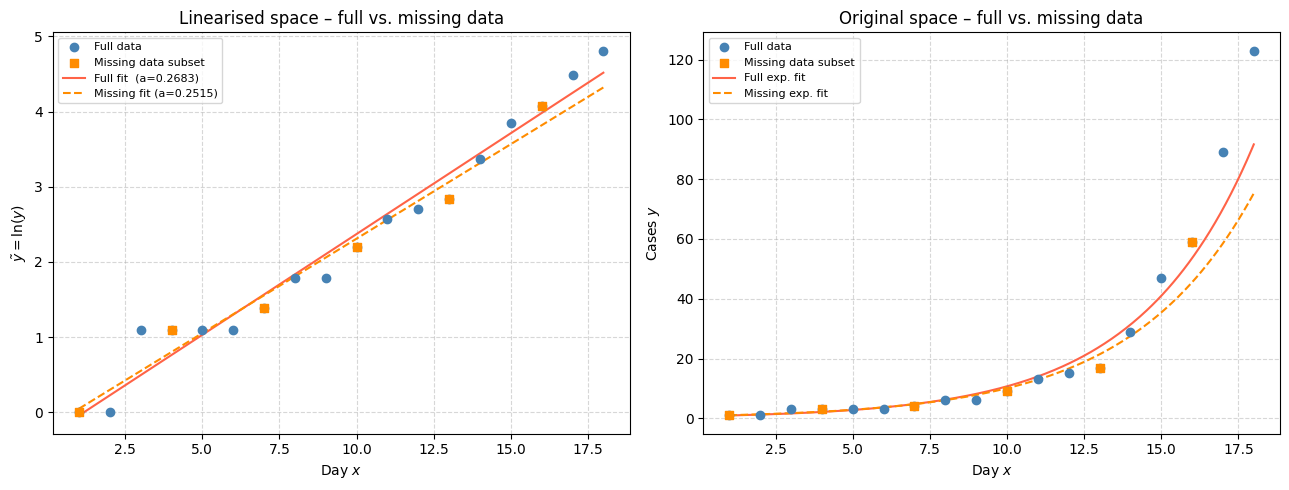

In [33]:
y_linear_fit_miss = a_miss * x_plot + b_miss
y_exp_fit_miss    = np.exp(a_miss * x_plot + b_miss)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: linearised space ---
ax = axes[0]
ax.scatter(x_full, y_tilde_full, color='steelblue', zorder=5, label='Full data')
ax.scatter(x_miss, y_tilde_miss, color='darkorange', marker='s', zorder=6, label='Missing data subset')
ax.plot(x_plot, y_linear_fit,      color='tomato',     label=f'Full fit  (a={a_full:.4f})')
ax.plot(x_plot, y_linear_fit_miss, color='darkorange', linestyle='--', label=f'Missing fit (a={a_miss:.4f})')
ax.set_xlabel('Day $x$')
ax.set_ylabel('$\\tilde{y} = \\ln(y)$')
ax.set_title('Linearised space – full vs. missing data')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.5)

# --- Right: original space ---
ax = axes[1]
ax.scatter(x_full, y_full, color='steelblue', zorder=5, label='Full data')
ax.scatter(x_miss, y_miss, color='darkorange', marker='s', zorder=6, label='Missing data subset')
ax.plot(x_plot, y_exp_fit,      color='tomato',     label=f'Full exp. fit')
ax.plot(x_plot, y_exp_fit_miss, color='darkorange', linestyle='--', label=f'Missing exp. fit')
ax.set_xlabel('Day $x$')
ax.set_ylabel('Cases $y$')
ax.set_title('Original space – full vs. missing data')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [34]:
y_pred_miss = np.exp(a_miss * x_pred + b_miss)
rel_error_miss = abs(y_pred_miss - y_actual) / y_actual * 100

print(f"Extrapolation to day {int(x_pred)} (missing-data model):")
print(f"  Model prediction : {y_pred_miss:.2f}")
print(f"  Actual value     : {y_actual:.0f}")
print(f"  Relative error   : {rel_error_miss:.2f}%")
print()
print("Summary comparison:")
print(f"  Full dataset  → prediction {y_pred_full:.1f},  error {rel_error_full:.1f}%")
print(f"  Missing data  → prediction {y_pred_miss:.1f},  error {rel_error_miss:.1f}%")

Extrapolation to day 30 (missing-data model):
  Model prediction : 1538.18
  Actual value     : 1029
  Relative error   : 49.48%

Summary comparison:
  Full dataset  → prediction 2293.6,  error 122.9%
  Missing data  → prediction 1538.2,  error 49.5%


In [35]:
# Given data points
x_data = np.array([0.132, 0.511, 0.701, 0.891, 1.081, 1.27,
                   1.46,  1.65,  1.839, 2.029, 2.219])
y_data = np.array([0.1,   0.543, 0.506, 0.606, 0.622, 0.569,
                   0.453, 0.438, 0.316, 0.29,  0.195])

print(f"Number of data points: {len(x_data)}")
print(f"x range: [{x_data.min()}, {x_data.max()}]")
print(f"y range: [{y_data.min()}, {y_data.max()}]")

Number of data points: 11
x range: [0.132, 2.219]
y range: [0.1, 0.622]


In [36]:
def weibull(x, a, b):
    """Full Weibull PDF: W(x, a, b) = a*b*x^(b-1)*exp(-a*x^b)"""
    return a * b * x**(b - 1) * np.exp(-a * x**b)

def residuals_full(params):
    """Residual vector r_i = W(x_i, a, b) - y_i."""
    a, b = params
    return weibull(x_data, a, b) - y_data

print("Model and residual function defined.")

Model and residual function defined.


In [37]:
p0 = [1.0, 2.0]
result_full = least_squares(residuals_full, p0, method='lm')

a_opt, b_opt = result_full.x
res_norm_full = np.linalg.norm(result_full.fun)

print("Full Weibull model  W(x, a, b) = a·b·x^(b-1)·exp(-a·x^b)")
print(f"  Converged       : {result_full.success}")
print(f"  Message         : {result_full.message}")
print(f"  a               = {a_opt:.6f}")
print(f"  b               = {b_opt:.6f}")
print(f"  Residual norm   = {res_norm_full:.6f}")

Full Weibull model  W(x, a, b) = a·b·x^(b-1)·exp(-a·x^b)
  Converged       : True
  Message         : `ftol` termination condition is satisfied.
  a               = 0.517088
  b               = 1.965840
  Residual norm   = 0.124463


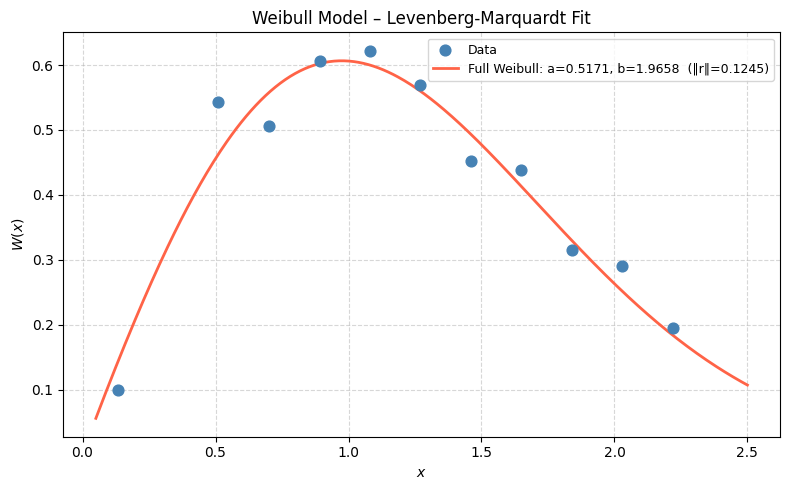

In [38]:
x_plot = np.linspace(0.05, 2.5, 400)
y_full_fit = weibull(x_plot, a_opt, b_opt)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(x_data, y_data, color='steelblue', zorder=5, s=60, label='Data')
ax.plot(x_plot, y_full_fit, color='tomato', linewidth=2,
        label=f'Full Weibull: a={a_opt:.4f}, b={b_opt:.4f}  (‖r‖={res_norm_full:.4f})')

ax.set_xlabel('$x$')
ax.set_ylabel('$W(x)$')
ax.set_title('Weibull Model – Levenberg-Marquardt Fit')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [39]:
def weibull_reduced(x, a):
    """Reduced model with b=2 fixed: Wr(x, a) = 2*a*x*exp(-a*x^2)"""
    return 2 * a * x * np.exp(-a * x**2)

def residuals_reduced(params):
    a = params[0]
    return weibull_reduced(x_data, a) - y_data

p0_r = [1.0]
result_reduced = least_squares(residuals_reduced, p0_r, method='lm')

a_opt_r = result_reduced.x[0]
res_norm_reduced = np.linalg.norm(result_reduced.fun)

print("Reduced Weibull model  Wr(x, a) = 2·a·x·exp(-a·x²)  [b = 2 fixed]")
print(f"  Converged       : {result_reduced.success}")
print(f"  a               = {a_opt_r:.6f}")
print(f"  Residual norm   = {res_norm_reduced:.6f}")
print()
print("Model comparison:")
print(f"  Full    (2 params): ‖r‖ = {res_norm_full:.6f},  a = {a_opt:.4f}, b = {b_opt:.4f}")
print(f"  Reduced (1 param) : ‖r‖ = {res_norm_reduced:.6f},  a = {a_opt_r:.4f}, b = 2.0000 (fixed)")
print(f"  Residual norm increase: {(res_norm_reduced - res_norm_full):.6f}  "
      f"({(res_norm_reduced / res_norm_full - 1) * 100:.2f}%)")
print()
print("Conclusion: b ≈ 2 in the full model → b is not an essential free parameter.")
print("The reduced model fits nearly as well with one fewer degree of freedom.")

Reduced Weibull model  Wr(x, a) = 2·a·x·exp(-a·x²)  [b = 2 fixed]
  Converged       : True
  a               = 0.511722
  Residual norm   = 0.126233

Model comparison:
  Full    (2 params): ‖r‖ = 0.124463,  a = 0.5171, b = 1.9658
  Reduced (1 param) : ‖r‖ = 0.126233,  a = 0.5117, b = 2.0000 (fixed)
  Residual norm increase: 0.001770  (1.42%)

Conclusion: b ≈ 2 in the full model → b is not an essential free parameter.
The reduced model fits nearly as well with one fewer degree of freedom.


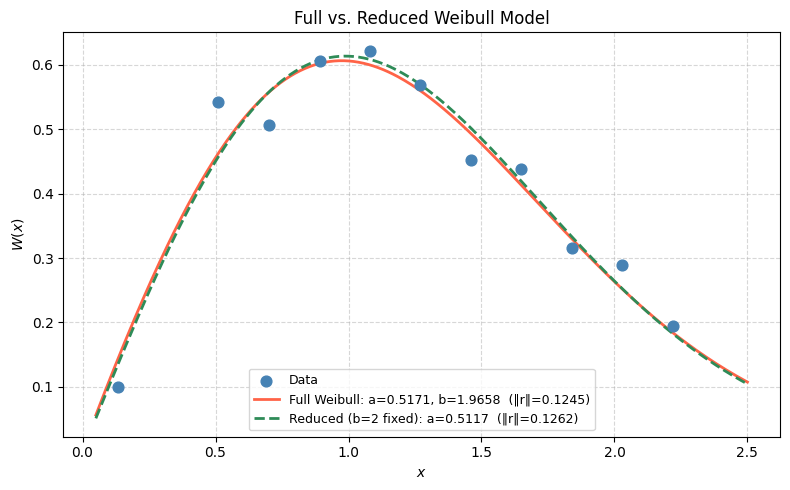

In [40]:
y_reduced_fit = weibull_reduced(x_plot, a_opt_r)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(x_data, y_data, color='steelblue', zorder=5, s=60, label='Data')
ax.plot(x_plot, y_full_fit, color='tomato', linewidth=2,
        label=f'Full Weibull: a={a_opt:.4f}, b={b_opt:.4f}  (‖r‖={res_norm_full:.4f})')
ax.plot(x_plot, y_reduced_fit, color='seagreen', linewidth=2, linestyle='--',
        label=f'Reduced (b=2 fixed): a={a_opt_r:.4f}  (‖r‖={res_norm_reduced:.4f})')

ax.set_xlabel('$x$')
ax.set_ylabel('$W(x)$')
ax.set_title('Full vs. Reduced Weibull Model')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()